In [1]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import requests
import warnings
import plotly.express as px
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import time
import json

# prison path from API
download_new_datasets = False

if download_new_datasets:
    # AI adoption API links
    prison_data_link = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/crim_pris_age/1.0/*.*.*.*.*?c[freq]=A&"
                        "c[age]=TOTAL&"
                        "c[sex]=T,M,F&"
                        "c[unit]=NR&"
                        "c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE&"
                        "c[TIME_PERIOD]=2023,2022,2021,2020,2019,2018,2017,2016,2015,2014&compress=false&"
                        "format=csvdata&formatVersion=2.0&"
                        "lang=en&labels=name")

    # Downloading the datasets and saving them as CSV files in the data folder
    prison_data_response = requests.get(prison_data_link)

    with open("../data/prison data/Prison_data.csv", "wb") as f:
        f.write(prison_data_response.content)

# Loading the datasets into pandas DataFrames
prison_data_df = pd.read_csv("../data/prison data/Prison_data.csv")
print(f"Prison Data DataFrame shape: {prison_data_df.shape[0]} rows, {prison_data_df.shape[1]} columns")

Prison Data DataFrame shape: 781 rows, 21 columns


/var/folders/d4/0xvzbpl17dg7jnk6kl8nfnqw0000gn/T/ipykernel_10609/1350707312.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns


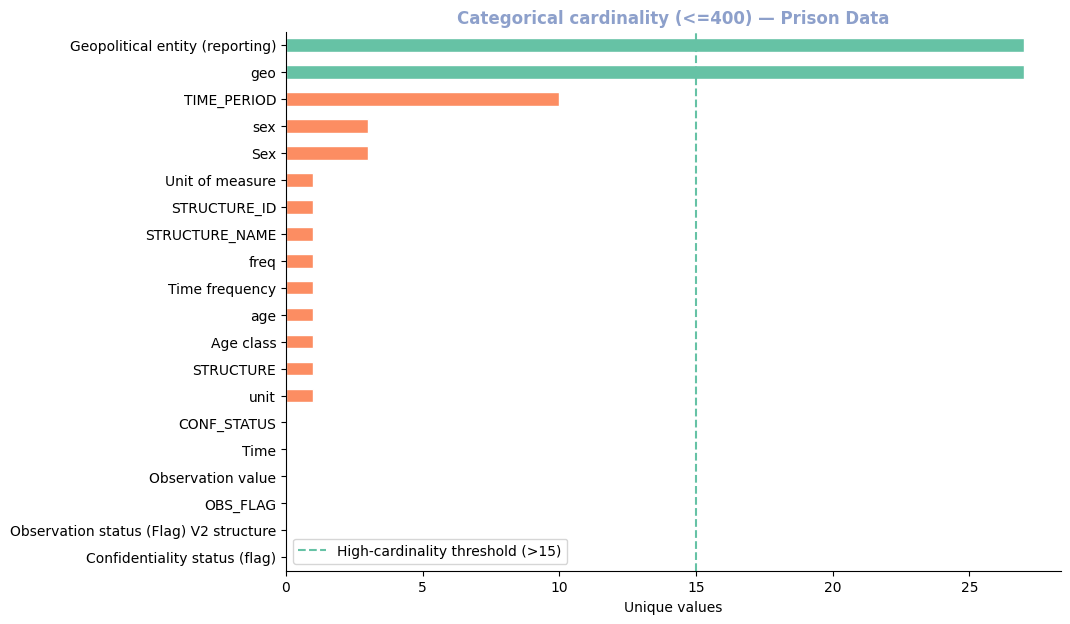

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 744 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'unit' (1 values): ['NR']

  'STRUCTURE' (1 values): ['dataflow']

  'Age class' (1 values): ['Total']

  'age' (1 values): ['TOTAL']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'Unit of measure' (1 values): ['Number']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'sex' (3 values): ['F', 'M', 'T']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AT', 'BE', 'BG

In [2]:
# cardinality of the dataset
YEARS = range(2008, 2024)
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data_df, "Prison Data")

In [3]:
country_codes = {
    "Austria": "AUT", "Belgium": "BEL", "Bulgaria": "BGR", 
    "Croatia": "HRV", "Cyprus": "CYP", "Czechia": "CZE", 
    "Estonia": "EST", "Finland": "FIN", "France": "FRA",
    "Germany": "DEU", "Greece": "GRC", "Hungary": "HUN",
    "Ireland": "IRL", "Italy": "ITA","Denmark": "DNK",
    "Latvia": "LVA", "Romania": "ROU",  "Slovakia": "SVK",
    "Lithuania": "LTU", "Luxembourg": "LUX", "Malta": "MLT",
    "Netherlands": "NLD", "Poland": "POL", "Portugal": "PRT",
    "Slovenia": "SVN", "Spain": "ESP", "Sweden": "SWE",
}
area_km2 = {
    "Albania": 28748, "Austria": 83879, "Belgium": 30689,
    "Bulgaria": 110994, "Croatia": 56594, "Poland": 312696,
    "Cyprus": 9251, "Czechia": 78871, "Denmark": 42952,
    "Estonia": 45339, "Finland": 338455, "France": 643801,
    "Germany": 357596, "Greece": 131957, "Hungary": 93030,
     "Ireland": 70273, "Italy": 302068, "Portugal": 92212,
    "Latvia": 64589, "Switzerland": 41285, "Türkiye": 783562,
    "Lithuania": 65300, "Luxembourg": 2586, "Malta": 316,
    "Romania": 238397, "Slovakia": 49035, "Netherlands": 41865, 
    "Slovenia": 20271, "Spain": 505990, "Sweden": 450295, "EU Average": 10530000
}
# Sessione con retry automatici
session = requests.Session()
retry = Retry(
    total=5,
    backoff_factor=2,                              # attese: 2s, 4s, 8s, 16s, 32s
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))

# Cache su disco — evita di rifare chiamate già riuscite
CACHE_FILE = Path("worldbank_population_cache.json")
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        _cache = json.load(f)
else:
    _cache = {}
def get_population_world_bank(iso3_code, start_year=2008, end_year=2023):
    cache_key = f"{iso3_code}_{start_year}_{end_year}"
    if cache_key in _cache:
        # converti chiavi anno da str (JSON) a int
        return {int(k): v for k, v in _cache[cache_key].items()}
    url = (
        f"https://api.worldbank.org/v2/country/{iso3_code}/indicator/SP.POP.TOTL"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    try:
        response = session.get(url, timeout=(15, 90))   # (connect, read)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
            print(f"[warn] nessun dato per {iso3_code}")
            return {}
        result = {
            int(item["date"]): int(item["value"])
            for item in payload[1]
            if item.get("value") is not None
        }
        # salva in cache
        _cache[cache_key] = result
        with open(CACHE_FILE, "w") as f:
            json.dump(_cache, f)
        return result
    except requests.exceptions.RequestException as e:
        print(f"[warn] errore per {iso3_code}: {e}")
        return {}

country_info = {}
for country, code in country_codes.items():
    country_info[country] = {
        "area_km2": area_km2[country],
        "population_by_year": get_population_world_bank(code, 2008, 2023),
    }
# Manual mapping for regions not in World Bank API
country_info["England and Wales"] = {"area_km2": 151244, "population_by_year": None, "population_fixed": 59641000}
country_info["Scotland (NUTS 2021)"] = {"area_km2": 78803, "population_by_year": None, "population_fixed": 5480000}
country_info["Northern Ireland (UK) (NUTS 2021)"] = {"area_km2": 14333, "population_by_year": None, "population_fixed": 1905000}

# Assign columns after country_info is fully built
prison_data_df["geo"] = prison_data_df["Geopolitical entity (reporting)"].map(country_codes)
prison_data_df["area_km2"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("area_km2")
)
prison_data_df["population_by_year"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_by_year")
)
prison_data_df["population_fixed"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_fixed")
)

In [4]:
def resolve_population(row):
    if row["population_fixed"] is not None and not (isinstance(row["population_fixed"], float) and pd.isna(row["population_fixed"])):
        return row["population_fixed"]
    pop_dict = row["population_by_year"]
    if isinstance(pop_dict, dict):
        return pop_dict.get(row["TIME_PERIOD"])
    return None
prison_data_df["population_year"] = prison_data_df.apply(resolve_population, axis=1)

prison_data_df["Total"] = prison_data_df["OBS_VALUE"].where(prison_data_df["Unit of measure"] == "Number")

prison_data_df["PerHundred"] = (prison_data_df["Total"] * 100000 / prison_data_df["population_year"]).round(2)

prison_data_df.sample(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag),area_km2,population_by_year,population_fixed,population_year,Total,PerHundred
5,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,F,Females,NR,...,NaN,NaN,NaN,NaN,83879,"{2023: 9131761, 2022: 9041851, 2021: 8955797, ...",None,8879920,606,6.82
229,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,F,Females,NR,...,NaN,NaN,NaN,NaN,450295,"{2023: 10536632, 2022: 10486941, 2021: 1041581...",None,9799186,327,3.34
610,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,505990,"{2023: 48352528, 2022: 47786102, 2021: 4744382...",None,47786102,55751,116.67
104,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,F,Females,NR,...,NaN,NaN,NaN,NaN,643801,"{2023: 68372286, 2022: 68184457, 2021: 6784281...",None,67382061,2511,3.73
639,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,NR,...,NaN,NaN,NaN,NaN,56594,"{2023: 3859686, 2022: 3855641, 2021: 3878981, ...",None,3878981,3905,100.67


In [5]:
# Drop columns 
prison_data_df.drop(columns=[
    'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex',
    'Confidentiality status (flag)', 'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS',
    'STRUCTURE', 'Observation status (Flag) V2 structure', 'Unit of measure', 'OBS_VALUE',
    'population_by_year', 'population_fixed'], inplace=True)

prison_data_df.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total,PerHundred
322,Total,Males,EST,Estonia,2020,45339,1329522,2251,169.31
419,Total,Males,LUX,Luxembourg,2018,2586,607950,623,102.48
194,Total,Females,NLD,Netherlands,2020,41865,17441500,514,2.95
358,Total,Males,FRA,France,2016,643801,66724104,66167,99.17
117,Total,Females,HRV,Croatia,2022,56594,3855641,219,5.68


In [6]:
gender_path = Path('../data/Data to export//cleaned_gender_index.csv')
gender_data = pd.read_csv(gender_path)

gender_data = gender_data.melt(
    id_vars='Country', var_name='TIME_PERIOD', value_name='Gender_index'
)
gender_data['TIME_PERIOD'] = gender_data['TIME_PERIOD'].astype(int)
# add a column to prison_data with the gender index for each country and year
prison_data = prison_data_df.merge(
    gender_data,
    left_on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    right_on=['Country', 'TIME_PERIOD'],
    how='left'
).drop(columns='Country')
prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Total,PerHundred,Gender_index
218,Total,Females,ROU,Romania,2014,238397,19908979,1537,7.72,0.6936
347,Total,Males,FIN,Finland,2015,338455,5479531,2898,52.89,0.8500
405,Total,Males,LTU,Lithuania,2014,65300,2937253,8256,281.08,0.7208
486,Total,Males,SWE,Sweden,2015,450295,9799186,5364,54.74,0.8230
263,Total,Males,AUT,Austria,2020,83879,8916864,7934,88.98,0.7440


In [7]:
EU_cols = ['TIME_PERIOD', 'Age class', 'Sex']

eu_agg = prison_data.groupby(EU_cols, as_index=False).agg(
    population_year=('population_year', 'sum'),
    Total=('Total', 'sum'),
    Gender_index=('Gender_index', 'mean'),
    PerHundred=('PerHundred', 'sum')
)
eu_agg['area_km2'] = area_km2['EU Average']  
eu_agg['geo'] = 'EU'
eu_agg['Geopolitical entity (reporting)'] = 'EU Average'

eu_agg = eu_agg[prison_data.columns]
prison_data_with_eu = pd.concat([prison_data, eu_agg], ignore_index=True)
prison_data_with_eu['is_eu_avg'] = np.where(
    prison_data_with_eu['Geopolitical entity (reporting)'] == 'EU Average', 1, 0 )

# printa filtra per EU Average
print(prison_data_with_eu[prison_data_with_eu['Geopolitical entity (reporting)'] == 'EU Average'])

    Age class      Sex geo Geopolitical entity (reporting)  TIME_PERIOD  \
781     Total  Females  EU                      EU Average         2014   
782     Total    Males  EU                      EU Average         2014   
783     Total    Total  EU                      EU Average         2014   
784     Total  Females  EU                      EU Average         2015   
785     Total    Males  EU                      EU Average         2015   
786     Total    Total  EU                      EU Average         2015   
787     Total  Females  EU                      EU Average         2016   
788     Total    Males  EU                      EU Average         2016   
789     Total    Total  EU                      EU Average         2016   
790     Total  Females  EU                      EU Average         2017   
791     Total    Males  EU                      EU Average         2017   
792     Total    Total  EU                      EU Average         2017   
793     Total  Females  E

/var/folders/d4/0xvzbpl17dg7jnk6kl8nfnqw0000gn/T/ipykernel_10609/1350707312.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns


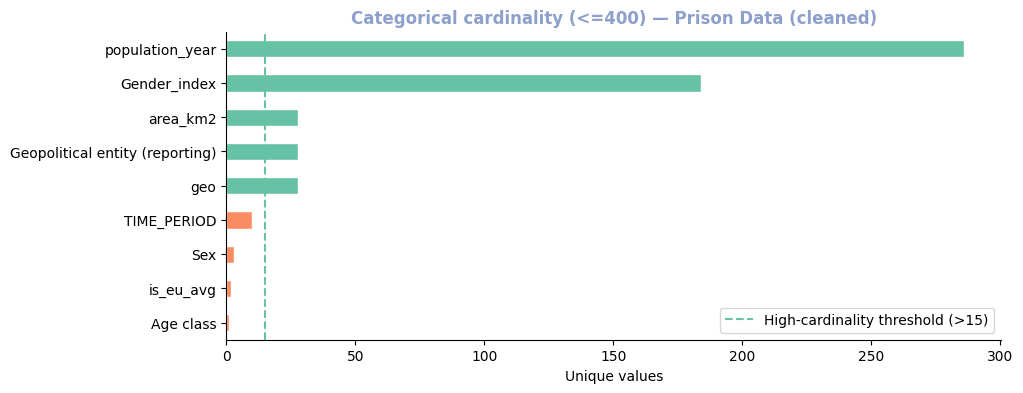

HIGH-CARDINALITY features (excluded from chart):
    'PerHundred': 769 unique values — needs grouping/target encoding
    'Total': 774 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (1 values): ['Total']

  'is_eu_avg' (2 values): ['0', '1']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (28 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'EU', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (28 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'EU Average', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Ro

In [8]:
inspect_categorical(prison_data_with_eu, "Prison Data (cleaned)")

In [9]:
# Save the cleaned dataset in Data to export folder
prison_data_with_eu.to_csv('../data/Data to export/cleaned_prison_data.csv', index=False)

In [16]:
# After manuel input of missing values reload the dataset with the new values
# DON'T RUN THE PREVIOUS CELLS
final_prison_data = pd.read_csv('../data/Data to export/final_prison_data.csv')
final_prison_data.columns = final_prison_data.columns.str.strip()

In [17]:
# Parameters
TIME_PERIOD = 2017          # Anno disponibile: 2014-2023
SEX         = 'Total'     # Opzioni: 'Females', 'Males', 'Total'

# Validazione parametri
assert TIME_PERIOD in final_prison_data['TIME_PERIOD'].unique(), \
    f"Anno non valido. Disponibili: {sorted(final_prison_data['TIME_PERIOD'].unique())}"
assert SEX in final_prison_data['Sex'].unique(), \
    f"Sesso non valido. Opzioni: {final_prison_data['Sex'].unique().tolist()}"

filtered = final_prison_data[
    (final_prison_data['TIME_PERIOD'] == TIME_PERIOD) &
    (final_prison_data['Sex']         == SEX)         
]
# Aggrega per paese
agg = (
    filtered.groupby('Geopolitical entity (reporting)')['Total']
    .mean()
    .reset_index()
)
agg.columns = ['country', 'value']
agg['value'] = agg['value'].round(1)
agg['iso3']  = agg['country'].map(country_codes)
agg = agg[agg['iso3'].notna()].copy()

print(f"Paesi con dati disponibili: {len(agg)}")
print(agg.sort_values('value', ascending=False).to_string(index=False))

# Mappa statica
fig = px.choropleth(
    agg,
    locations='iso3',
    color='value',
    hover_name='country',
    hover_data={'value': ':.1f', 'iso3': False},
    color_continuous_scale='YlOrRd',
    labels={'value': 'Per 100k abitanti'},
    title=f'Detenuti per 100.000 abitanti — Europa'
          f'<br><sup>Anno: {TIME_PERIOD} | Genere: {SEX}</sup>',
    scope='europe',
)
fig.update_geos(
    visible=True, resolution=50,
    showcoastlines=True, coastlinecolor='#444',
    showland=True,  landcolor='#2d2d3e',
    showocean=True, oceancolor='#1a1a2e',
    showlakes=True, lakecolor='#1a1a2e',
    showframe=False,
    projection_type='natural earth',
    lataxis_range=[34, 72], lonaxis_range=[-25, 45],
    bgcolor='#1a1a2e',
)
fig.update_layout(
    title_font=dict(size=18, color='white'),
    paper_bgcolor='#1a1a2e',
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Per 100k abitanti', font=dict(color='white', size=12)),
        tickfont=dict(color='white'),
        bgcolor='rgba(30,30,50,0.8)',
        bordercolor='#555', borderwidth=1,
        len=0.7, thickness=15,
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
)
# Disabilita interattività — mappa statica
fig.show(config={
    'staticPlot': False,       # nessun zoom/pan/hover
    'displayModeBar': False,  # nasconde la toolbar
})

Paesi con dati disponibili: 27
    country   value iso3
     Poland 74480.0  POL
     France 68974.0  FRA
    Germany 64193.0  DEU
      Italy 59038.0  ITA
      Spain 58812.0  ESP
    Romania 23450.0  ROU
    Czechia 22159.0  CZE
    Hungary 17343.0  HUN
   Portugal 13587.0  PRT
Netherlands 10874.0  NLD
    Belgium 10471.0  BEL
   Slovakia 10028.0  SVK
     Greece 10011.0  GRC
    Austria  8852.0  AUT
   Bulgaria  6988.0  BGR
  Lithuania  6599.0  LTU
     Sweden  5713.0  SWE
     Latvia  3765.0  LVA
    Ireland  3680.0  IRL
    Denmark  3418.0  DNK
    Croatia  3190.0  HRV
    Finland  3082.0  FIN
    Estonia  2723.0  EST
   Slovenia  1316.0  SVN
 Luxembourg   684.0  LUX
     Cyprus   592.0  CYP
      Malta   591.0  MLT


-----

In [12]:
# --- ANALYSIS: Female adult prisoners vs Gender Index ---

# Filter: females, adults only, exclude EU Average
prison_female = prison_data_with_eu[
    (prison_data_with_eu['Sex'] == 'Females') &
    (prison_data_with_eu['Age class'] == 'Adult') &
    (prison_data_with_eu['Geopolitical entity (reporting)'] != 'EU Average')
].copy()

# Quick check
print(f"Rows: {len(prison_female)}")
print(f"Countries: {prison_female['Geopolitical entity (reporting)'].nunique()}")
print(f"Years: {sorted(prison_female['TIME_PERIOD'].unique())}")
print(f"\nSample:")
print(prison_female[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'PerHundred', 'Gender_index']].head(10))
print(f"\nMissing values:\n{prison_female[['PerHundred', 'Gender_index']].isna().sum()}")

Rows: 0
Countries: 0
Years: []

Sample:
Empty DataFrame
Columns: [Geopolitical entity (reporting), TIME_PERIOD, PerHundred, Gender_index]
Index: []

Missing values:
PerHundred      0
Gender_index    0
dtype: int64


In [13]:
from scipy import stats

# --- Rebuild prison_female using Age class == 'Total' from total_values ---

prison_female = prison_data_with_eu[
    (prison_data_with_eu['Sex'] == 'Females') &
    (prison_data_with_eu['Age class'] == 'Total') &
    (prison_data_with_eu['Geopolitical entity (reporting)'] != 'EU Average')
].copy()

prison_all = prison_data_with_eu[
    (prison_data_with_eu['Sex'] == 'Total') &
    (prison_data_with_eu['Age class'] == 'Total') &
    (prison_data_with_eu['Geopolitical entity (reporting)'] != 'EU Average')
][['Geopolitical entity (reporting)', 'TIME_PERIOD', 'Total']].rename(columns={'Total': 'Total_all'})

prison_female = prison_female.merge(
    prison_all,
    on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    how='left'
)

prison_female['Female_pct'] = (prison_female['Total'] / prison_female['Total_all'] * 100).round(2)

print(f"Rows: {len(prison_female)}, Missing Female_pct: {prison_female['Female_pct'].isna().sum()}")
print(prison_female[['Geopolitical entity (reporting)', 'TIME_PERIOD', 'PerHundred', 'Female_pct', 'Gender_index']].head(10))

# --- CORRELATIONS ---
clean = prison_female.dropna(subset=['Gender_index', 'PerHundred', 'Female_pct'])

r1, p1    = stats.pearsonr(clean['Gender_index'], clean['PerHundred'])
rho1, p1s = stats.spearmanr(clean['Gender_index'], clean['PerHundred'])

r2, p2    = stats.pearsonr(clean['Gender_index'], clean['Female_pct'])
rho2, p2s = stats.spearmanr(clean['Gender_index'], clean['Female_pct'])

print("\n=== CORRELATIONS ===")
print(f"\nGender Index vs PerHundred (female prisoners per 100k):")
print(f"  Pearson  r = {r1:.3f}  (p = {p1:.4f})")
print(f"  Spearman r = {rho1:.3f}  (p = {p1s:.4f})")

print(f"\nGender Index vs Female % of total prisoners:")
print(f"  Pearson  r = {r2:.3f}  (p = {p2:.4f})")
print(f"  Spearman r = {rho2:.3f}  (p = {p2s:.4f})")

Rows: 257, Missing Female_pct: 0
  Geopolitical entity (reporting)  TIME_PERIOD  PerHundred  Female_pct  \
0                         Austria         2014        5.93        5.83   
1                         Austria         2015        5.76        5.75   
2                         Austria         2016        5.63        5.71   
3                         Austria         2017        5.89        5.85   
4                         Austria         2018        6.37        6.14   
5                         Austria         2019        6.82        6.68   
6                         Austria         2020        6.21        6.53   
7                         Austria         2021        5.88        6.25   
8                         Austria         2022        6.62        6.66   
9                         Austria         2023        6.72        6.76   

   Gender_index  
0        0.7266  
1        0.7330  
2        0.7160  
3        0.7090  
4        0.7180  
5        0.7310  
6        0.7440  
7       

## Key finding: correlations

The analysis reveals two distinct patterns depending on how female incarceration is measured.

Female prisoners per 100,000 inhabitants shows a statistically significant negative correlation with the Gender Gap Index (Pearson r = −0.331, Spearman r = −0.347, p < 0.001 for both). This means that countries with higher gender equality consistently imprison fewer women relative to their population — a robust finding that holds across both parametric and non-parametric tests.

Female share of total prisoners tells a different story. The Pearson correlation is negligible and non-significant (r = −0.068, p = 0.274), while the Spearman coefficient is only marginally significant (ρ = −0.126, p = 0.043). This suggests that gender equality is not meaningfully associated with how women are represented within prisons relative to men, but rather with the absolute rate at which women are incarcerated.

In other words: in more gender-equal countries, fewer women end up in prison overall — but this reduction does not substantially alter the male-to-female ratio within prisons, likely because male incarceration also varies considerably across countries for independent reasons.

In [14]:
# Use average per country per year (already one row per country-year in prison_female)
map_data = prison_female.dropna(subset=['Female_pct']).copy()
map_data['TIME_PERIOD'] = map_data['TIME_PERIOD'].astype(str)

fig = px.choropleth(
    map_data,
    locations='geo',
    color='Female_pct',
    hover_name='Geopolitical entity (reporting)',
    hover_data={'Female_pct': ':.2f', 'geo': False},
    animation_frame='TIME_PERIOD',
    color_continuous_scale='YlOrRd',
    labels={'Female_pct': 'Female % of prisoners'},
    title='Female Share of Prison Population (%) — Europe (2014–2023)',
    scope='europe',
)
fig.update_geos(
    visible=True, resolution=50,
    showcoastlines=True, coastlinecolor='#444',
    showland=True,  landcolor='#2d2d3e',
    showocean=True, oceancolor='#1a1a2e',
    showlakes=True, lakecolor='#1a1a2e',
    showframe=False,
    projection_type='natural earth',
    lataxis_range=[34, 72], lonaxis_range=[-25, 45],
    bgcolor='#1a1a2e',
)
fig.update_layout(
    title_font=dict(size=16, color='white'),
    paper_bgcolor='#1a1a2e',
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Female %', font=dict(color='white', size=12)),
        tickfont=dict(color='white'),
        bgcolor='rgba(30,30,50,0.8)',
        bordercolor='#555', borderwidth=1,
        len=0.7, thickness=15,
    ),
    margin=dict(l=0, r=0, t=60, b=0),
    height=650,
)
# Slow down animation
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 400

fig.show()

In [15]:
# --- SUMMARY STATS FOR NARRATIVE ---

clean = prison_female.dropna(subset=['Gender_index', 'PerHundred', 'Female_pct']).copy()

# 1. EU average Female_pct per year
eu_pct_by_year = clean.groupby('TIME_PERIOD')['Female_pct'].mean().round(2)
print("=== EU Average Female % by year ===")
print(eu_pct_by_year)

# 2. Overall EU average Female_pct (2014-2023)
print(f"\nOverall EU average Female %: {clean['Female_pct'].mean():.2f}%")

# 3. Country averages (2014-2023) — top and bottom 5 by Female_pct
country_avg = clean.groupby('Geopolitical entity (reporting)')[['Female_pct', 'PerHundred', 'Gender_index']].mean().round(2)
print("\n=== Top 5 countries by Female % (avg 2014-2023) ===")
print(country_avg.sort_values('Female_pct', ascending=False).head(5))
print("\n=== Bottom 5 countries by Female % (avg 2014-2023) ===")
print(country_avg.sort_values('Female_pct', ascending=False).tail(5))

# 4. Country averages — top and bottom 5 by PerHundred
print("\n=== Top 5 countries by PerHundred (avg 2014-2023) ===")
print(country_avg.sort_values('PerHundred', ascending=False).head(5))
print("\n=== Bottom 5 countries by PerHundred (avg 2014-2023) ===")
print(country_avg.sort_values('PerHundred', ascending=False).tail(5))

# 5. Change from 2014 to 2023 at EU level
for metric in ['Female_pct', 'PerHundred']:
    val_2014 = clean[clean['TIME_PERIOD'] == 2014][metric].mean()
    val_2023 = clean[clean['TIME_PERIOD'] == 2023][metric].mean()
    print(f"\n{metric}: 2014 avg = {val_2014:.2f} → 2023 avg = {val_2023:.2f} (Δ = {val_2023 - val_2014:+.2f})")

=== EU Average Female % by year ===
TIME_PERIOD
2014    5.37
2015    5.42
2016    5.39
2017    5.46
2018    5.53
2019    5.75
2020    5.58
2021    5.83
2022    5.77
2023    5.79
Name: Female_pct, dtype: float64

Overall EU average Female %: 5.59%

=== Top 5 countries by Female % (avg 2014-2023) ===
                                 Female_pct  PerHundred  Gender_index
Geopolitical entity (reporting)                                      
Malta                                  8.13       10.52          0.69
Latvia                                 7.97       15.18          0.77
Czechia                                7.72       14.75          0.69
Finland                                7.60        4.10          0.84
Hungary                                7.53       13.63          0.68

=== Bottom 5 countries by Female % (avg 2014-2023) ===
                                 Female_pct  PerHundred  Gender_index
Geopolitical entity (reporting)                                      
Poland        